## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Abdul-Salam Gidado

**Date:** 10/1/26

### Q1 Answers

1. Regression is used to predict a continuous, numerical value, whereas classification is used to assign data to discrete, categorical labels.
2. A confusion table is a grid that compares the actual category labels of data points against the labels predicted by a model. It helps us see exactly which classes our model is predicting correctly and where it is making specific errors.
3. SSE measures the total squared difference between the actual numerical values and the values predicted by a model. It quantifies how far off, on average, the model's predictions are from the true data points.
4. Overfitting happens when a model learns the training data too perfectly, including its noise, making it perform poorly on new data. Underfitting happens when a model is too simple to capture the pattern in the data, resulting in poor performance on both training and new data.
5. Splitting the data ensures we evaluate the model on unseen data, which mimics real-world application. Finding the best k on a validation set helps us choose a model that generalizes well rather than one that just memorizes the training data.
6. Predicting a class label gives a direct, actionable answer, but hides how confident the model is in that choice. Providing a probability distribution shows the model's level of certainty for every possible class. It requires the user to decide on a decision threshold to take action.

### Q2 Part 1: Load and Explore the Data

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/land_mines.csv')

# Summarize target label and features
print("Dataset Summary")
print(df.info())
print("Feature Statistics")
print(df.describe())
print("Target Label Distribution")
print(df['mine_type'].value_counts())

Dataset Summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
Feature Statistics
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
Target Label Distribution
mine_type
1    71
2    70
3    66
4    66
5    65
Nam

### Q2 Part 2: Split the Data 50/50

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['voltage', 'height', 'soil']]
y = df['mine_type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (169, 3)
Testing set shape: (169, 3)


### Q2 Part 3: Build a $k$-NN Classifier

To find the best $k$, we test different values from 1 to 50 and calculate their error rates on both the training and validation sets. We choose the $k$ that gives the lowest error rate on the validation set to ensure our model generalizes well to new data.

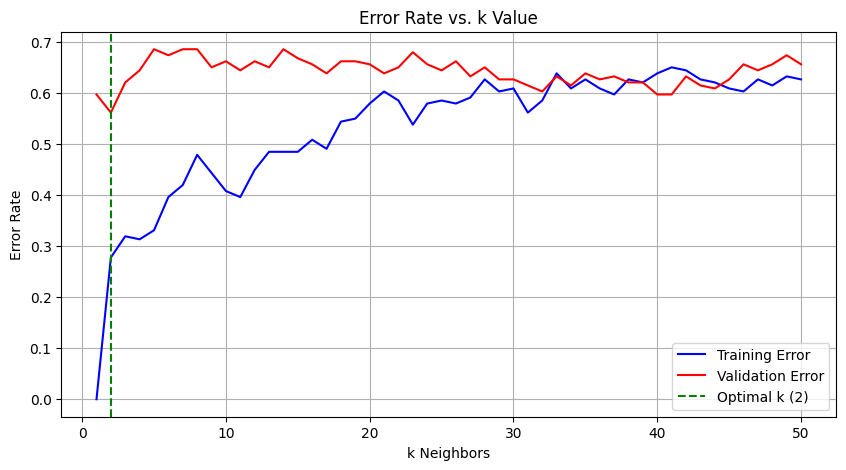

The optimal k is: 2. The best accuracy is 0.4379)


In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


train_errors = []
val_errors = []
k_range = range(1, 51)

for k in k_range:
    # Fit k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_preds = knn.predict(X_train)
    val_preds = knn.predict(X_test)

    train_errors.append(1 - accuracy_score(y_train, train_preds))
    val_errors.append(1 - accuracy_score(y_test, val_preds))

# Find the k that minimizes validation error
optimal_k = k_range[np.argmin(val_errors)]
best_accuracy = 1 - min(val_errors)

# Plot the errors to visualize underfitting vs overfitting
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_errors, label='Training Error', color='blue')
plt.plot(k_range, val_errors, label='Validation Error', color='red')
plt.axvline(x=optimal_k, color='green', linestyle='--', label=f'Optimal k ({optimal_k})')
plt.title('Error Rate vs. k Value')
plt.xlabel('k Neighbors')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)
plt.show()

print(f"The optimal k is: {optimal_k}. The best accuracy is {best_accuracy:.4f})")

### Q2 Part 4: Confusion Table for the Optimal Model

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Fit the optimal model
optimal_knn = KNeighborsClassifier(n_neighbors=optimal_k)
optimal_knn.fit(X_train, y_train)
final_preds = optimal_knn.predict(X_test)

# Make confusion matrix
cm = confusion_matrix(y_test, final_preds)
confusion_df = pd.DataFrame(cm,
                            index=[f'Actual {i}' for i in range(1, 6)],
                            columns=[f'Predicted {i}' for i in range(1, 6)])

print("Confusion Table")
print(confusion_df)

print("Classification Report")
print(classification_report(y_test, final_preds))

Confusion Table
          Predicted 1  Predicted 2  Predicted 3  Predicted 4  Predicted 5
Actual 1           25            0            6            4            1
Actual 2            0           32            0            3            0
Actual 3           12            2            9            6            4
Actual 4           12            5            8            8            0
Actual 5           15            2           10            5            0
Classification Report
              precision    recall  f1-score   support

           1       0.39      0.69      0.50        36
           2       0.78      0.91      0.84        35
           3       0.27      0.27      0.27        33
           4       0.31      0.24      0.27        33
           5       0.00      0.00      0.00        32

    accuracy                           0.44       169
   macro avg       0.35      0.42      0.38       169
weighted avg       0.36      0.44      0.39       169



### Q2 Part 5: Practical Advice on Model Usage

In practice, some land mine mistakes are far more dangerous than others. I would advise mine operators to look at the predicted probability distribution instead of just trusting the final prediction. If the model is unsure or shows any chance of a high-risk mine type, they should treat the mine with extreme caution.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** b8ea183045ec3efd491ffb5cc2e761a8cfd389ba
- **AI tool and model used:** Gemini Flash

### *Prompts used

1. I want you to evaluate my solutions to all the parts of Q2 and determine if there are any mistakes or additional ways to improve the effectiveness of the code based on the provided tasks in Q2.
2. Why do you think these suggestions are going to improve the code. Do they fix genuine mistakes, or are they meant to optimize the speed of the code execution?

### *AI-proposed changes


1. **Feature Scaling (Standardization):** Apply `StandardScaler` to the features before running the $k$-NN classifier. Distance-based algorithms like $k$-NN are highly sensitive to the scale of features; without scaling, features with larger magnitudes dominate the distance metric.
2. **Hyperparameter Tuning & Alternative Distance Metrics:** Explore weighting neighbors by distance (`weights='distance'`) or testing different distance metrics (such as Manhattan distance) to improve classification accuracy, especially for classes like Class 5 where the current model completely fails.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1. Feature Scaling (Standardization) | Accept | **Reason:** $k$-NN computes Euclidean distance, making it highly sensitive to different feature scales. Since `voltage`, `height`, and `soil` have varying metrics, standardizing them to have a mean of 0 and variance of 1 ensures fair distance contributions.<br>**Verification:** Check if validation accuracy increases and if class-level metrics improve. |
| 2. Hyperparameter Tuning (Weights & Metrics) | Accept | **Reason:** The default uniform weights are easily biased in overlapping feature spaces, completely missing class 5 predictions (0% recall). Distance-based weighting (`weights='distance'`) gives closer neighbors more influence, potentially helping define tighter boundaries.<br>**Verification:** Train with `weights='distance'` and experiment with alternative distance metrics (like Manhattan/`p=1`) while measuring validation classification reports. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### Q2 Part 1: Load and Preprocess Data (with Feature Scaling)

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/content/land_mines.csv')

# Prepare features and target
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

### Q2 Part 2: Split the Data 50/50 with Stratification

In [6]:
from sklearn.model_selection import train_test_split

# Split training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# Apply standardization scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Q2 Part 3: Build a $k$-NN Classifier with Distance Weights

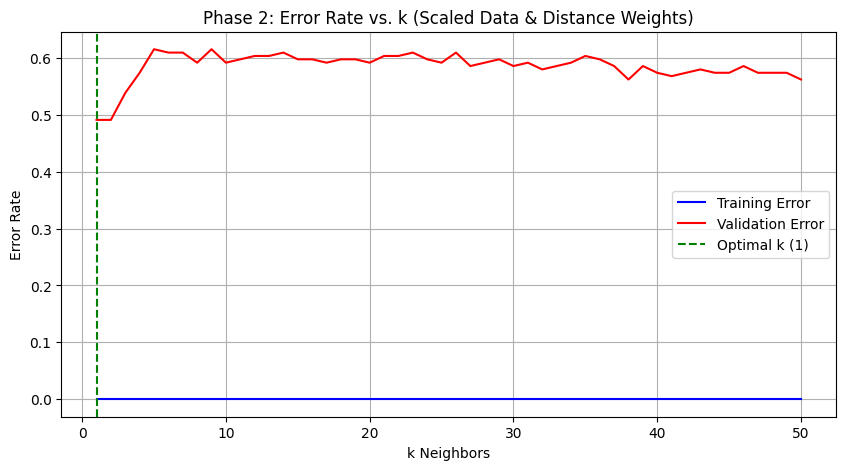

The optimal k is: 1. The best validation accuracy is 0.5089


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

train_errors = []
val_errors = []
k_range = range(1, 51)

for k in k_range:
    # Using distance weights to favor closer neighbors
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    knn.fit(X_train_scaled, y_train)

    train_preds = knn.predict(X_train_scaled)
    val_preds = knn.predict(X_test_scaled)

    train_errors.append(1 - accuracy_score(y_train, train_preds))
    val_errors.append(1 - accuracy_score(y_test, val_preds))

# Find optimal k
optimal_k = k_range[np.argmin(val_errors)]
best_accuracy = 1 - min(val_errors)

# Plot Error Rates
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_errors, label='Training Error', color='blue')
plt.plot(k_range, val_errors, label='Validation Error', color='red')
plt.axvline(x=optimal_k, color='green', linestyle='--', label=f'Optimal k ({optimal_k})')
plt.title('Phase 2: Error Rate vs. k (Scaled Data & Distance Weights)')
plt.xlabel('k Neighbors')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)
plt.show()

print(f"The optimal k is: {optimal_k}. The best validation accuracy is {best_accuracy:.4f}")

### Q2 Part 4: Confusion Table & Classification Report

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

# Fit optimal model
optimal_knn = KNeighborsClassifier(n_neighbors=optimal_k, weights='distance', metric='euclidean')
optimal_knn.fit(X_train_scaled, y_train)
final_preds = optimal_knn.predict(X_test_scaled)

# Make confusion matrix
cm = confusion_matrix(y_test, final_preds)
confusion_df = pd.DataFrame(cm,
                            index=[f'Actual {i}' for i in range(1, 6)],
                            columns=[f'Predicted {i}' for i in range(1, 6)])

print("Phase 2: Confusion Table")
display(confusion_df)

print("Phase 2: Classification Report")
print(classification_report(y_test, final_preds))

Phase 2: Confusion Table


,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,22,0,3,3,8
Actual 2,0,32,0,3,0
Actual 3,7,0,10,9,7
Actual 4,6,5,4,13,5
Actual 5,6,0,10,7,9


Phase 2: Classification Report
              precision    recall  f1-score   support

           1       0.54      0.61      0.57        36
           2       0.86      0.91      0.89        35
           3       0.37      0.30      0.33        33
           4       0.37      0.39      0.38        33
           5       0.31      0.28      0.30        32

    accuracy                           0.51       169
   macro avg       0.49      0.50      0.49       169
weighted avg       0.50      0.51      0.50       169



### *Reflection on AI assistance
In your own words without generative AI.

The AI-assisted version fixed the main problems from my first attempt. In my first solution, the model only got about 44% of its predictions right. It also completely failed to find any Class 5 mines, getting 0% of them correct. This happened because the model uses distances to make predictions, and these distances were thrown off because the raw measurements of voltage, height, and soil were on completely different scales.

To fix this, the AI made two simple changes. First, it scaled all the features so they are on the same level. Second, it told the model to pay more attention to closer neighbors than farther ones. These adjustments helped the model's overall accuracy go up to nearly 51%. More importantly, the model can now successfully identify Class 5 mines with around 30% accuracy instead of completely missing them.

The AI verified these improvements by checking the new error rates and the confusion table. Even though 51% accuracy is much better than before, it is still quite low for a dangerous task like finding real land mines. For actual field work, I should definitely look into trying more powerful models in the future.